# Instalação das dependência do scikit learn

       Nome  Disponibilidade  Idade  Cluster
0     Lucas              4.0     19        1
1   Letícia              3.5     20        1
2    Oliver              2.0     27        0
3     Paulo              2.0     39        0
4    Márcia              4.5     36        1
5   Alfredo              5.0     60        2
6   Matheus              3.5     18        1
7     Luísa              4.0     60        2
8  Ludmilla              4.0     21        1


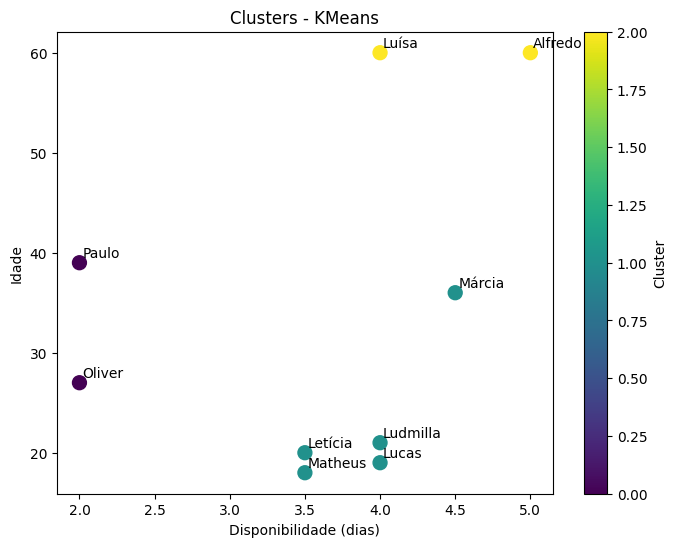

In [ ]:
# Instalar bibliotecas (se necessário)
!pip install scikit-learn matplotlib pandas --quiet

# Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Criar o DataFrame
dados = {
    "Nome": ["Lucas", "Letícia", "Oliver", "Paulo", "Márcia",
             "Alfredo", "Matheus", "Luísa", "Ludmilla"],
    "Disponibilidade": [4, 3.5, 2, 2, 4.5, 5, 3.5, 4, 4],
    "Idade": [19, 20, 27, 39, 36, 60, 18, 60, 21]
}

df = pd.DataFrame(dados)

# Selecionar apenas as variáveis numéricas
X = df[["Disponibilidade", "Idade"]]

# Normalizar os dados (importante para KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Definir número de clusters (você pode alterar)
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Mostrar resultado
print(df)

# Visualização gráfica
plt.figure(figsize=(8,6))
plt.scatter(df["Disponibilidade"], df["Idade"],
            c=df["Cluster"], cmap="viridis", s=100)

for i, nome in enumerate(df["Nome"]):
    plt.text(df["Disponibilidade"][i]+0.02,
             df["Idade"][i]+0.5,
             nome)

plt.xlabel("Disponibilidade (dias)")
plt.ylabel("Idade")
plt.title("Clusters - KMeans")
plt.colorbar(label="Cluster")
plt.show()

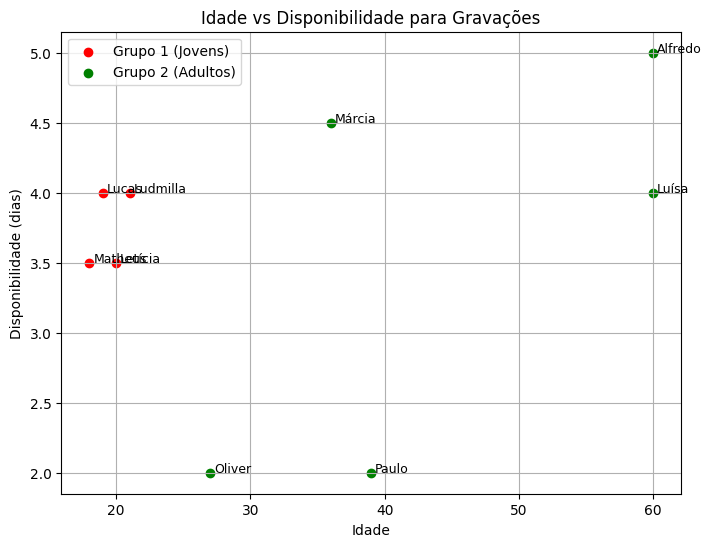

In [ ]:
# Definindo cores diferentes para os dois grupos
group1 = df[df['Idade'] <= 24] # Jovens com menos disponibilidade
group2 = df[df['Idade'] > 24] # Adultos com mais disponibilidade
# Criando o gráfico novamente com cores distintas
plt.figure(figsize=(8,6))
# Plotando o grupo 1
plt.scatter(group1['Idade'], group1['Disponibilidade'], color='red', label='Grupo 1 (Jovens)')
for i, nome in enumerate(group1['Nome']):
    plt.text(group1['Idade'].values[i] + 0.3, group1['Disponibilidade'].values[i], nome, fontsize=9)
# Plotando o grupo 2
plt.scatter(group2['Idade'], group2['Disponibilidade'], color='green', label='Grupo 2 (Adultos)')
for i, nome in enumerate(group2['Nome']):
    plt.text(group2['Idade'].values[i] + 0.3, group2['Disponibilidade'].values[i], nome, fontsize=9)
# Definindo labels e título do gráfico
plt.xlabel('Idade')
plt.ylabel('Disponibilidade (dias)')
plt.title('Idade vs Disponibilidade para Gravações')
plt.legend()
plt.grid(True)
plt.show()